In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import os
import sys
import logging

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [2]:
# load file path from ocean
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/myofiber_type2.h5ad'
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp'

In [3]:
from os.path import basename
import stream as st
adata = st.read(file_name=adata_infile_fiber, workdir=out_tmp)

/ocean/projects/cis240075p/asachan/.conda/envs/env_stream/lib/python3.7/site-packages/rpy2/robjects/pandas2ri.py:17: FutureWarning: pandas.core.index is deprecated and will be removed in a future version.  The public classes are available in the top-level namespace.
  from pandas.core.index import Index as PandasIndex


Saving results in: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp


In [4]:
adata

AnnData object with n_obs × n_vars = 65973 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'orig.ident_colors', 'rank_genes_groups', 'sample_colors', 'workdir'
    obsm: 'X_umap'

In [5]:
# convert to dense
adata.X = adata.X.toarray()
adata.X.shape
adata.X.mean()
adata.X.min()
adata.X.max()


4.537766352922828

In [6]:
st.cal_qc(adata,assay='rna')

In [7]:
st.filter_cells(adata,min_n_features= 200)
st.filter_features(adata,min_n_cells = 10)

filter cells based on min_n_features
after filtering out low-quality cells: 
65973 cells, 48355 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
65973 cells, 35797 genes


In [8]:
###Normalize gene expression based on library size  
st.normalize(adata,method='lib_size')
###Logarithmize gene expression 
st.log_transform(adata)
###Remove mitochondrial genes 
st.remove_mt_genes(adata)

remove mitochondrial genes:
['MT-RNR1', 'MT-RNR2', 'MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB', 'MT-TF', 'MT-TV', 'MT-TL1', 'MT-TM']


In [9]:
import numpy as np
import scipy.sparse as sp

X = adata.X
if sp.issparse(X):
    data = X.data
    data[np.isnan(data)] = 0
    X.eliminate_zeros()
else:
    np.nan_to_num(X, copy=False)  # in-place: NaN->0, inf->large finite

In [10]:
n_nans = np.isnan(X.data).sum() if sp.issparse(X) else np.isnan(X).sum()
display(n_nans)
display(adata.X.size)

0

2360381994

### Stream dim reduction

7156 variable genes are selected


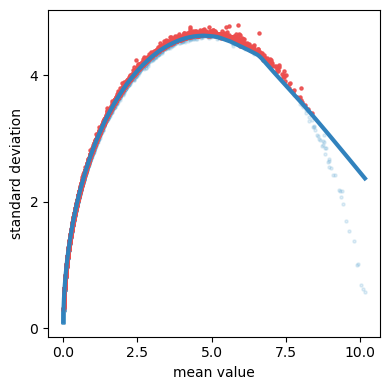

In [11]:
# # Setting var_genes if you need to select top 3k genes from a list of more than 3k genes
st.select_variable_genes(adata,loess_frac=0.01,percentile=80)

In [ ]:
# # 'var_genes' vs 'all' : use top % or all genes from .var ; if using all make sure the adata is subsetted to only the highly variable genes
# # n_components = Number of branches present in your biological differentation
st.dimension_reduction(adata,method='se',feature='var_genes',n_components=2,n_neighbors=30,n_jobs=64) # using the same knn as diffusion maps (default is 30)